Лаб №5.

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.decomposition import FastICA
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/paddydataset.csv')
print("Информация о датасете:")
dataset.head()

Информация о датасете:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


Пункт 1.

In [4]:
vals = dataset["Soil Types"].unique()
vals

array(['alluvial', 'clay'], dtype=object)

In [5]:
cols_for_clusters = ['Hectares ','Seedrate(in Kg)','LP_Mainfield(in Tonnes)','Nursery area (Cents)']
df= dataset[cols_for_clusters].copy()
df.head()

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents)
0,6,150,75.0,120
1,6,150,75.0,120
2,6,150,75.0,120
3,6,150,75.0,120
4,6,150,75.0,120


In [6]:
X = df
y, yvals = pd.factorize(dataset["Soil Types"])
print(f"Уникальные классы: {yvals}")
print(f"Закодированные метки (первые 5): {y[:5]}")

Уникальные классы: Index(['alluvial', 'clay'], dtype='object')
Закодированные метки (первые 5): [0 1 0 1 0]


Пункт 2. PCA

Применяем PCA: 4 признаков -> 4 компонент

Объясненная дисперсия по компонентам:
  PC1: 1.0000 (100.00%), Кумулятивно: 1.0000 (100.00%)
  PC2: 0.0000 (0.00%), Кумулятивно: 1.0000 (100.00%)
  PC3: 0.0000 (0.00%), Кумулятивно: 1.0000 (100.00%)
  PC4: 0.0000 (0.00%), Кумулятивно: 1.0000 (100.00%)

Суммарная объясненная дисперсия (первые 4 компонент): 1.0000 (100.00%)


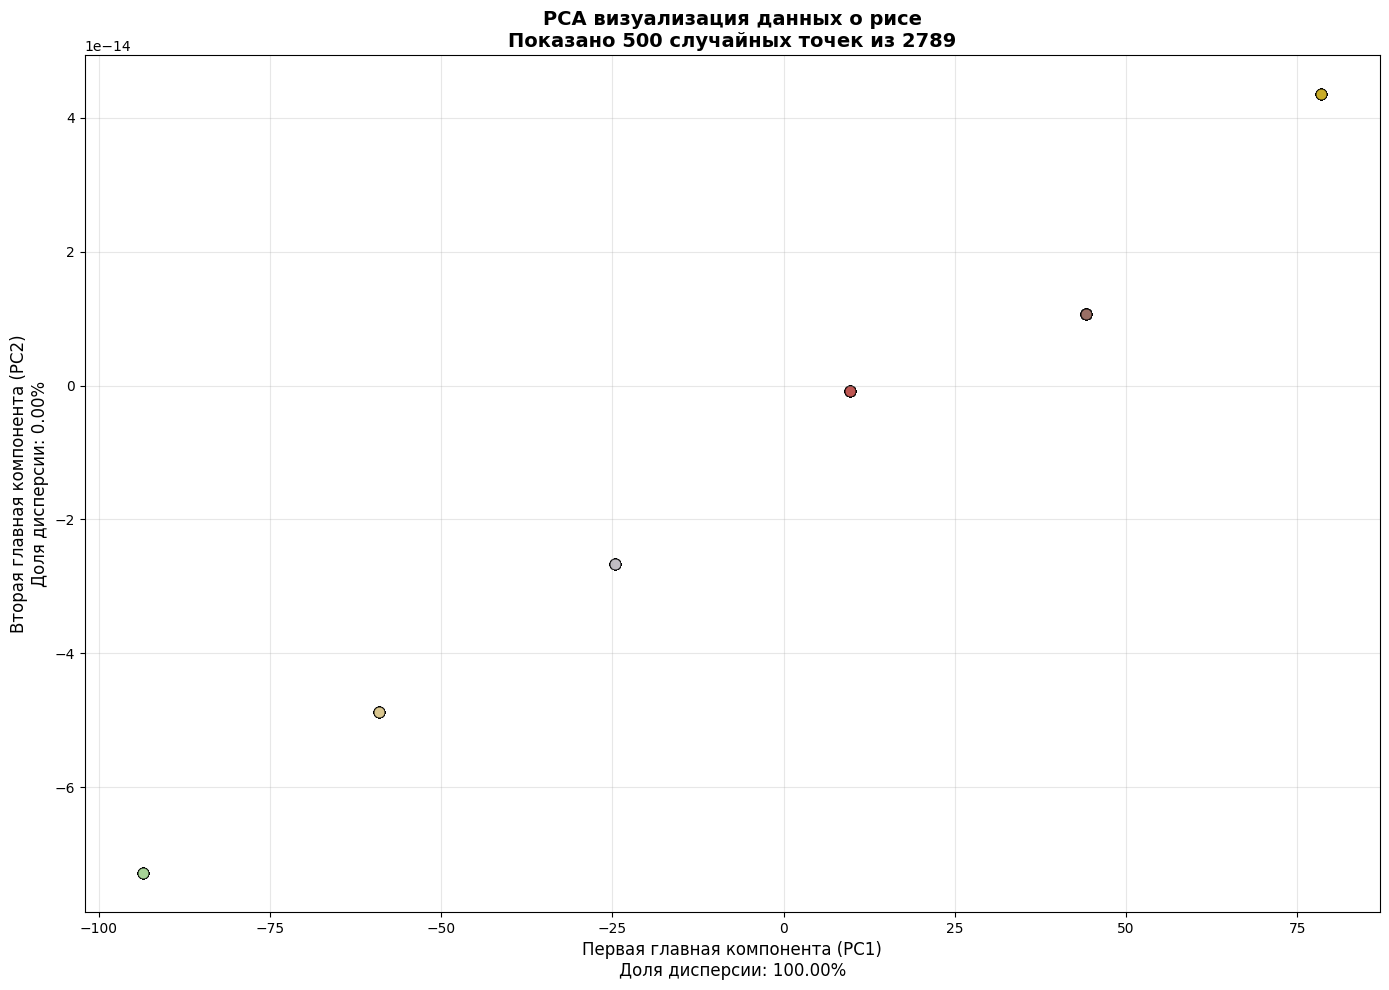

In [9]:
n_components = min(8, X.shape[1])
print(f"Применяем PCA: {X.shape[1]} признаков -> {n_components} компонент")

pca = PCA(n_components=n_components)
X_new = pca.fit_transform(X)

print(f"\nОбъясненная дисперсия по компонентам:")
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative = np.sum(pca.explained_variance_ratio_[:i+1])
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%), Кумулятивно: {cumulative:.4f} ({cumulative*100:.2f}%)")

print(f"\nСуммарная объясненная дисперсия (первые {n_components} компонент): {np.sum(pca.explained_variance_ratio_):.4f} ({np.sum(pca.explained_variance_ratio_)*100:.2f}%)")

np.random.seed(42)
sample_size = min(500, len(X_new))
sample_indices = np.random.choice(len(X_new), size=sample_size, replace=False)

plt.figure(figsize=(14, 10))

if hasattr(X, 'columns'):
    feature_names = X.columns.tolist()
else:
    feature_names = [f'Feature_{i}' for i in range(X.shape[1])]

colors = plt.cm.tab20(np.linspace(0, 1, min(sample_size, 20)))

for i, idx in enumerate(sample_indices):
    color_idx = idx % min(sample_size, 20)
    plt.scatter(
        X_new[idx, 0],
        X_new[idx, 1],
        color=colors[color_idx],
        alpha=0.7,
        s=60,
        edgecolor='black',
        linewidth=0.5
    )

plt.xlabel(f"Первая главная компонента (PC1)\nДоля дисперсии: {pca.explained_variance_ratio_[0]:.2%}",
           fontsize=12)
plt.ylabel(f"Вторая главная компонента (PC2)\nДоля дисперсии: {pca.explained_variance_ratio_[1]:.2%}",
           fontsize=12)
plt.title(f"PCA визуализация данных о рисе\nПоказано {sample_size} случайных точек из {len(X_new)}",
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if 'labels' in locals() and labels is not None:
    plt.figure(figsize=(14, 10))

    labels_sample = labels[sample_indices] if len(labels) > sample_size else labels

    scatter = plt.scatter(
        X_new[sample_indices, 0],
        X_new[sample_indices, 1],
        c=labels_sample,
        cmap='viridis',
        alpha=0.7,
        s=60,
        edgecolor='black',
        linewidth=0.5
    )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=12)
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=12)
    plt.title(f"PCA визуализация с цветовой маркировкой по кластерам\nПоказано {sample_size} точек",
              fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Cluster ID')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Пункт 3. ICA

Применяем ICA (Independent Component Analysis): 4 признаков -> 4 компонент


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)



Размер преобразованных данных: (2789, 4)

Статистика ICA:
  Количество итераций: 500
  Отбеливание применено: Да


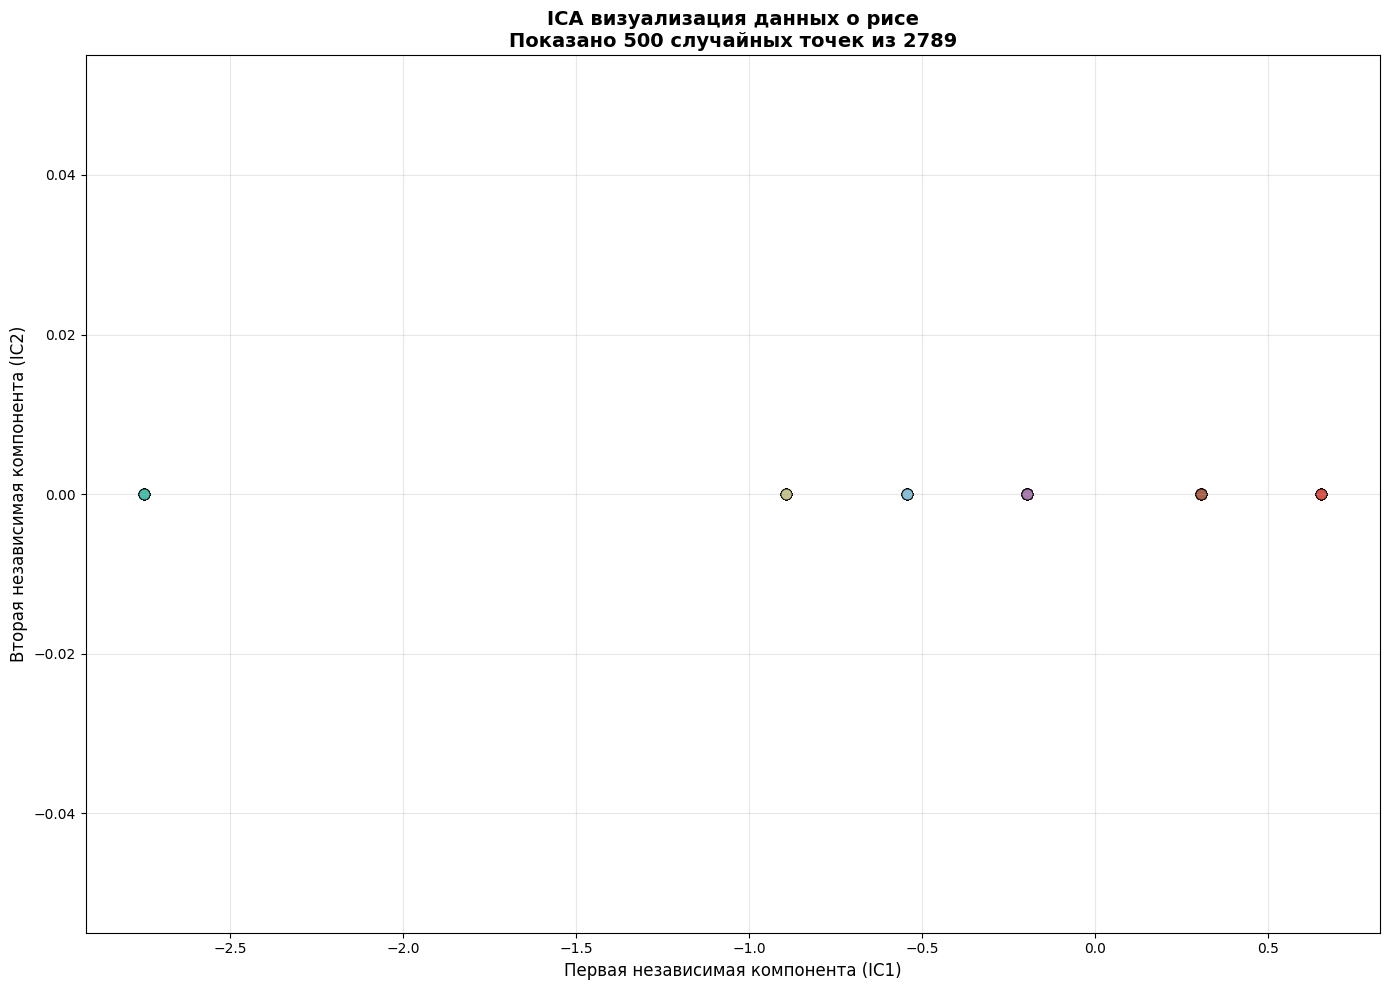

In [12]:
n_components = min(8, X.shape[1])
print(f"Применяем ICA (Independent Component Analysis): {X.shape[1]} признаков -> {n_components} компонент")

ica = FastICA(n_components=n_components, random_state=42, max_iter=500)
X_new = ica.fit_transform(X)

print(f"\nРазмер преобразованных данных: {X_new.shape}")

print(f"\nСтатистика ICA:")
print(f"  Количество итераций: {ica.n_iter_}")
if hasattr(ica, 'whitening_'):
    print(f"  Отбеливание применено: Да")

plt.figure(figsize=(14, 10))

np.random.seed(42)
n_samples = min(500, len(X_new))
sample_indices = np.random.choice(len(X_new), size=n_samples, replace=False)

colors = plt.cm.tab20(np.linspace(0, 1, min(n_samples, 20)))

for i, sample_idx in enumerate(sample_indices):
    color_idx = i % min(n_samples, 20)
    plt.scatter(
        X_new[sample_idx, 0],
        X_new[sample_idx, 1],
        color=colors[color_idx],
        alpha=0.7,
        s=60,
        edgecolor='black',
        linewidth=0.5
    )

plt.xlabel("Первая независимая компонента (IC1)", fontsize=12)
plt.ylabel("Вторая независимая компонента (IC2)", fontsize=12)
plt.title(f"ICA визуализация данных о рисе\nПоказано {n_samples} случайных точек из {len(X_new)}",
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Пункт 4. Kernel PCA

Тип X: <class 'pandas.core.frame.DataFrame'>
Размер X: (2789, 4)
Берем подвыборку из 1000 точек для Kernel PCA
Размер выборки: (1000, 4)
Данные стандартизированы (среднее=0, std=1)
KERNEL PCA АНАЛИЗ

1. Вычисляем Kernel PCA с RBF ядром...
   ✓ RBF ядро выполнено успешно
2. Вычисляем Kernel PCA с полиномиальным ядром...
   ✓ Полиномиальное ядро выполнено успешно
3. Вычисляем Kernel PCA с сигмоидным ядром...
   ✓ Сигмоидное ядро выполнено успешно


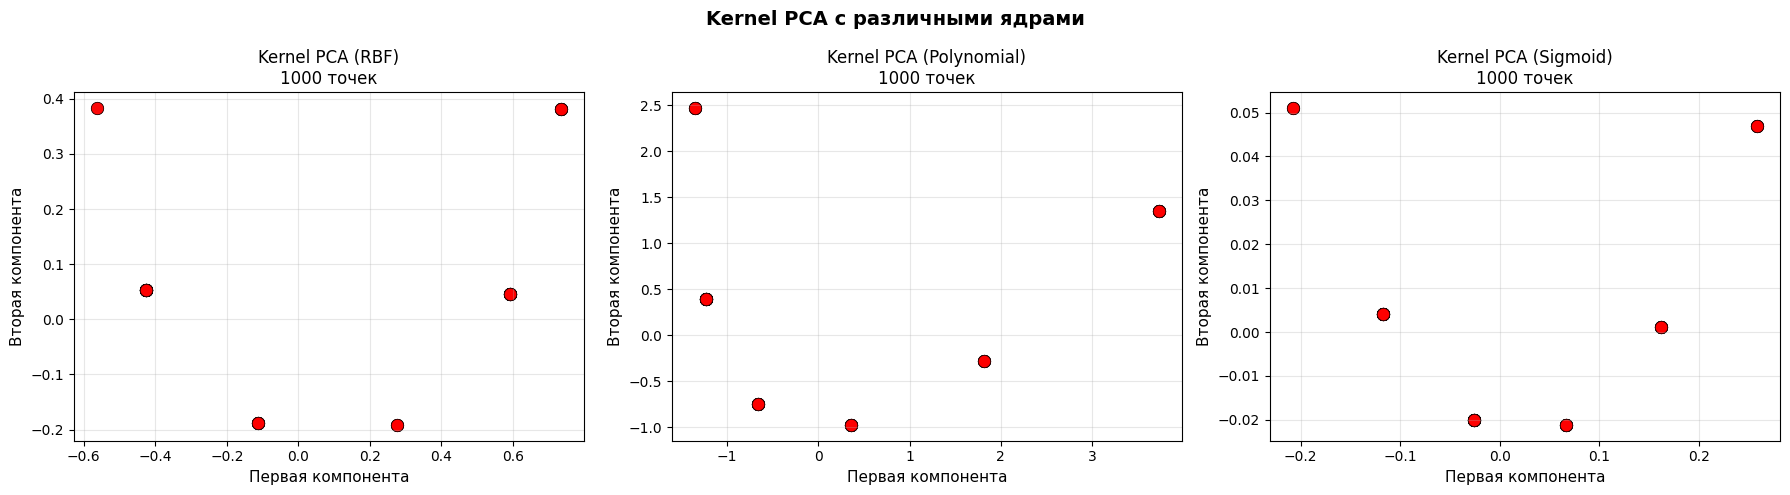

In [18]:
sample_size = min(1000, len(X))
print(f"Тип X: {type(X)}")
print(f"Размер X: {X.shape}")
print(f"Берем подвыборку из {sample_size} точек для Kernel PCA")

np.random.seed(42)
sample_indices = np.random.choice(len(X), size=sample_size, replace=False)

if hasattr(X, 'iloc'):
    X_sample = X.iloc[sample_indices]
else:
    X_sample = X[sample_indices]

scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

print(f"Размер выборки: {X_sample_scaled.shape}")
print(f"Данные стандартизированы (среднее=0, std=1)")

print("KERNEL PCA АНАЛИЗ")

print("\n1. Вычисляем Kernel PCA с RBF ядром...")
try:
    rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04, fit_inverse_transform=False)
    X_rbf = rbf_pca.fit_transform(X_sample_scaled)
    print("   ✓ RBF ядро выполнено успешно")
except Exception as e:
    print(f"   ✗ Ошибка RBF: {e}")
    X_rbf = None

print("2. Вычисляем Kernel PCA с полиномиальным ядром...")
try:
    poly_pca = KernelPCA(n_components=2, kernel='poly', degree=2, coef0=1, fit_inverse_transform=False)
    X_poly = poly_pca.fit_transform(X_sample_scaled)
    print("   ✓ Полиномиальное ядро выполнено успешно")
except Exception as e:
    print(f"   ✗ Ошибка полиномиального ядра: {e}")
    X_poly = None

print("3. Вычисляем Kernel PCA с сигмоидным ядром...")
try:
    sigmoid_pca = KernelPCA(n_components=2, kernel='sigmoid', gamma=0.01, coef0=-1, fit_inverse_transform=False)
    X_sigmoid = sigmoid_pca.fit_transform(X_sample_scaled)
    print("   ✓ Сигмоидное ядро выполнено успешно")
except Exception as e:
    print(f"   ✗ Ошибка сигмоидного ядра: {e}")
    print("   Пробуем с другими параметрами...")
    try:
        sigmoid_pca = KernelPCA(n_components=2, kernel='sigmoid', gamma=0.001, coef0=0, fit_inverse_transform=False)
        X_sigmoid = sigmoid_pca.fit_transform(X_sample_scaled)
        print("   ✓ Сигмоидное ядро (gamma=0.001) выполнено успешно")
    except:
        X_sigmoid = None
        print("   ✗ Сигмоидное ядро не работает, пропускаем")

successful_kernels = [('RBF', X_rbf), ('Polynomial', X_poly), ('Sigmoid', X_sigmoid)]
successful_kernels = [(name, X) for name, X in successful_kernels if X is not None]
n_kernels = len(successful_kernels)

if n_kernels > 0:
    fig, axes = plt.subplots(1, n_kernels, figsize=(6*n_kernels, 5))
    if n_kernels == 1:
        axes = [axes]

    for idx, (kernel_name, X_kernel) in enumerate(successful_kernels):
        axes[idx].scatter(
            X_kernel[:, 0],
            X_kernel[:, 1],
            c='lightblue',
            alpha=0.5,
            s=30
        )

        vis_indices = np.random.choice(len(X_kernel), size=min(50, len(X_kernel)), replace=False)
        axes[idx].scatter(
            X_kernel[vis_indices, 0],
            X_kernel[vis_indices, 1],
            c='red',
            alpha=0.8,
            s=80,
            edgecolors='black',
            linewidth=0.5
        )

        axes[idx].set_xlabel("Первая компонента", fontsize=11)
        axes[idx].set_ylabel("Вторая компонента", fontsize=11)
        axes[idx].set_title(f"Kernel PCA ({kernel_name})\n{sample_size} точек", fontsize=12)
        axes[idx].grid(True, alpha=0.3)

    plt.suptitle("Kernel PCA с различными ядрами", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Не удалось выполнить Kernel PCA ни с одним ядром")

Пункт 5. tSNE

Размер данных: (2789, 4)
Используемые признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)']...
Берем подвыборку из 2789 точек для t-SNE

Вычисляем t-SNE...
  Параметры: perplexity=30, n_iter=1000, learning_rate='auto'
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2789 samples in 0.003s...
[t-SNE] Computed neighbors for 2789 samples in 0.148s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2789
[t-SNE] Computed conditional probabilities for sample 2000 / 2789
[t-SNE] Computed conditional probabilities for sample 2789 / 2789
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 41.070568
[t-SNE] KL divergence after 1000 iterations: -3.599223

t-SNE завершен! Размер результата: (2789, 2)


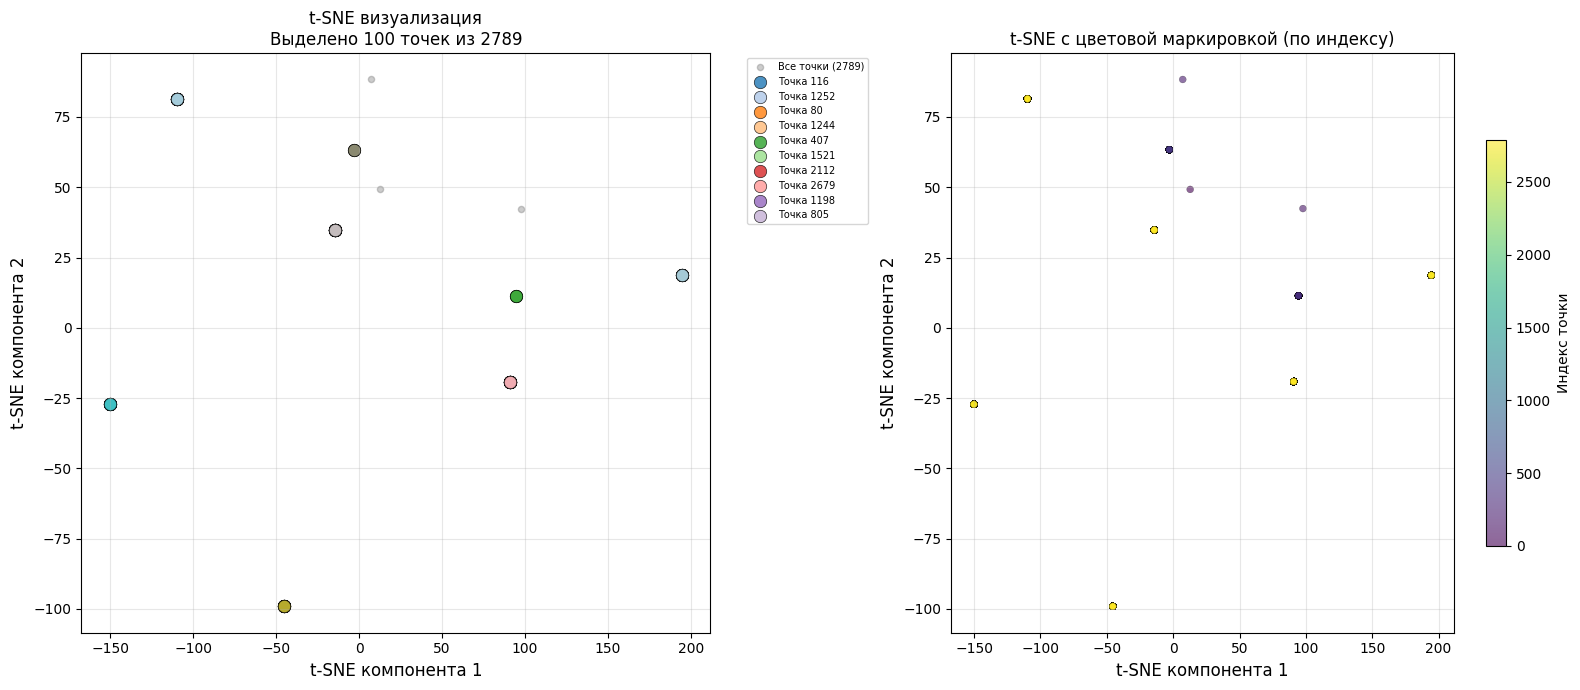

In [21]:
if isinstance(X, pd.DataFrame):
    X_array = X.values
    feature_names = X.columns.tolist()
else:
    X_array = X
    feature_names = [f'Feature_{i}' for i in range(X_array.shape[1])]

print(f"Размер данных: {X_array.shape}")
print(f"Используемые признаки: {feature_names[:5]}...")

sample_size = min(5000, len(X_array))
print(f"Берем подвыборку из {sample_size} точек для t-SNE")

np.random.seed(42)
sample_indices = np.random.choice(len(X_array), size=sample_size, replace=False)
X_sample = X_array[sample_indices]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

print("\nВычисляем t-SNE...")
print("  Параметры: perplexity=30, n_iter=1000, learning_rate='auto'")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    verbose=1,
    learning_rate='auto'
)
X_tsne = tsne.fit_transform(X_sample_scaled)

print(f"\nt-SNE завершен! Размер результата: {X_tsne.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c='gray',
    alpha=0.4,
    s=20,
    label=f'Все точки ({sample_size})'
)

n_vis = min(100, len(X_tsne))
vis_indices = np.random.choice(len(X_tsne), size=n_vis, replace=False)
colors = plt.cm.tab20(np.linspace(0, 1, min(n_vis, 20)))

for i, idx in enumerate(vis_indices):
    color_idx = i % min(n_vis, 20)
    axes[0].scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        color=colors[color_idx],
        alpha=0.8,
        s=80,
        edgecolors='black',
        linewidth=0.5,
        label=f'Точка {idx}' if i < 10 else ""
    )

axes[0].set_xlabel("t-SNE компонента 1", fontsize=12)
axes[0].set_ylabel("t-SNE компонента 2", fontsize=12)
axes[0].set_title(f"t-SNE визуализация\nВыделено {n_vis} точек из {sample_size}", fontsize=12)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axes[0].grid(True, alpha=0.3)

scatter = axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=range(sample_size),
    cmap='viridis',
    alpha=0.6,
    s=25,
    edgecolors='black',
    linewidth=0.2
)
axes[1].set_xlabel("t-SNE компонента 1", fontsize=12)
axes[1].set_ylabel("t-SNE компонента 2", fontsize=12)
axes[1].set_title(f"t-SNE с цветовой маркировкой (по индексу)", fontsize=12)
plt.colorbar(scatter, ax=axes[1], label='Индекс точки', shrink=0.7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Пункт 6.DBSCAN для кластеризации.

Размер данных: (2789, 4)
Признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)']...

Берем подвыборку из 2789 точек для DBSCAN
Данные стандартизированы (среднее=0, std=1)
ПОИСК ОПТИМАЛЬНЫХ ПАРАМЕТРОВ DBSCAN

Тестирование параметров:
  ✓ eps=0.3, min_samples=5: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.3, min_samples=10: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.3, min_samples=15: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.3, min_samples=20: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.5, min_samples=5: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.5, min_samples=10: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.5, min_samples=15: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.5, min_samples=20: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.8, min_samples=5: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.8, min_samples=10: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.8, min_samples=15: кластеров=6, шума=0 (0.0%)
  ✓ eps=0.8, min_samples=20: кластеров=6, шума=0 (0.0%)
  ✓ eps=1.0, min_samples=5: кластеров=6, шума=0 (0.0%)
  ✓ e

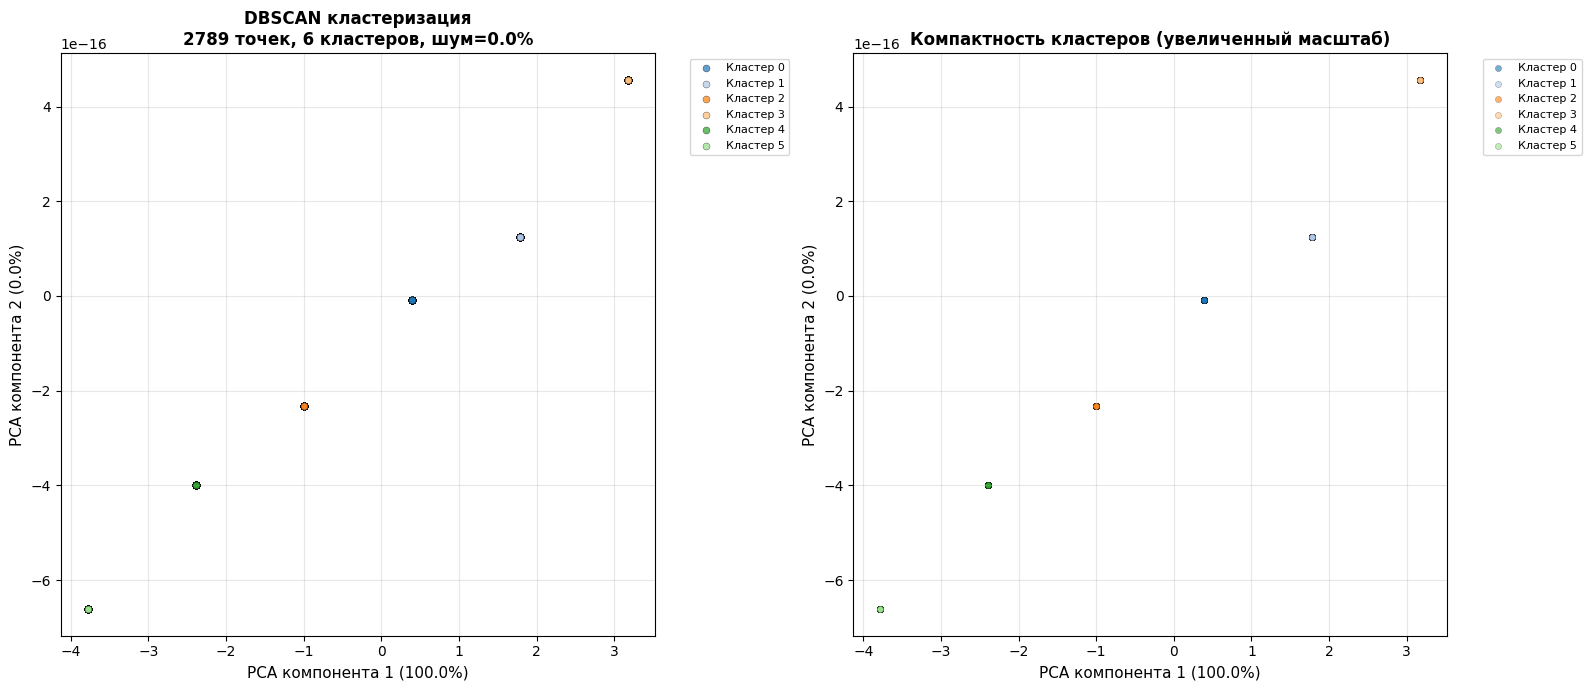

In [23]:
if isinstance(X, pd.DataFrame):
    X_array = X.values
    feature_names = X.columns.tolist()
else:
    X_array = X
    feature_names = [f'Feature_{i}' for i in range(X_array.shape[1])]

print(f"Размер данных: {X_array.shape}")
print(f"Признаки: {feature_names[:5]}...")

sample_size = min(3000, len(X_array))
print(f"\nБерем подвыборку из {sample_size} точек для DBSCAN")

np.random.seed(42)
sample_indices = np.random.choice(len(X_array), size=sample_size, replace=False)
X_sample = X_array[sample_indices]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

print("Данные стандартизированы (среднее=0, std=1)")

print("ПОИСК ОПТИМАЛЬНЫХ ПАРАМЕТРОВ DBSCAN")

eps_values = [0.3, 0.5, 0.8, 1.0, 1.5]
min_samples_values = [5, 10, 15, 20]

best_score = -1
best_params = None
best_labels = None

print("\nТестирование параметров:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_test = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        labels_test = dbscan_test.fit_predict(X_scaled)

        n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
        n_noise_test = list(labels_test).count(-1)
        noise_percent = n_noise_test / len(labels_test) * 100

        if n_clusters_test > 1 and noise_percent < 50:
            score = n_clusters_test * (1 - noise_percent/100)
            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)
                best_labels = labels_test

        status = "✓" if n_clusters_test > 0 else "✗"
        print(f"  {status} eps={eps}, min_samples={min_samples}: кластеров={n_clusters_test}, шума={n_noise_test} ({noise_percent:.1f}%)")

if best_params:
    eps, min_samples = best_params
    labels = best_labels
    print(f"\n✓ Выбраны оптимальные параметры: eps={eps}, min_samples={min_samples}")
else:
    eps, min_samples = 0.8, 10
    print(f"\n⚠ Используем параметры по умолчанию: eps={eps}, min_samples={min_samples}")
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
noise_percent = n_noise / len(labels) * 100

print("РЕЗУЛЬТАТЫ DBSCAN")
print(f"  Параметры: eps={eps}, min_samples={min_samples}")
print(f"  Количество кластеров: {n_clusters}")
print(f"  Количество шумовых точек: {n_noise} ({noise_percent:.1f}%)")
print(f"  Точки в кластерах: {len(labels) - n_noise} ({100-noise_percent:.1f}%)")
print(f"  Уникальные метки: {np.unique(labels)}")

if n_clusters > 0:
    print(f"\nРазмеры кластеров:")
    for label in sorted(set(labels)):
        if label != -1:
            count = np.sum(labels == label)
            percentage = count / len(labels) * 100
            print(f"  Кластер {label}: {count} точек ({percentage:.1f}%)")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nОбъясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 20)))

for label, color in zip(unique_labels, colors[:len(unique_labels)]):
    if label == -1:
        axes[0].scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            c='lightgray',
            alpha=0.4,
            s=15,
            label=f'Шум ({n_noise})'
        )
    else:
        axes[0].scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            c=[color],
            alpha=0.7,
            s=25,
            edgecolors='black',
            linewidth=0.3,
            label=f'Кластер {label}'
        )

axes[0].set_xlabel(f"PCA компонента 1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
axes[0].set_ylabel(f"PCA компонента 2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
axes[0].set_title(f"DBSCAN кластеризация\n{len(X_scaled)} точек, {n_clusters} кластеров, шум={noise_percent:.1f}%",
                  fontsize=12, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

if n_clusters > 0:
    cluster_colors = {}
    for label in unique_labels:
        if label != -1:
            cluster_colors[label] = colors[list(unique_labels).index(label)]

    for label in unique_labels:
        if label != -1:
            mask = labels == label
            if np.sum(mask) > 0:
                axes[1].scatter(
                    X_pca[mask, 0],
                    X_pca[mask, 1],
                    c=[cluster_colors[label]],
                    alpha=0.6,
                    s=20,
                    label=f'Кластер {label}',
                    edgecolors='black',
                    linewidth=0.2
                )

    noise_mask = labels == -1
    if np.sum(noise_mask) > 0:
        axes[1].scatter(
            X_pca[noise_mask, 0],
            X_pca[noise_mask, 1],
            c='lightgray',
            alpha=0.3,
            s=10,
            label='Шум'
        )

    axes[1].set_xlabel(f"PCA компонента 1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
    axes[1].set_ylabel(f"PCA компонента 2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
    axes[1].set_title("Компактность кластеров (увеличенный масштаб)", fontsize=12, fontweight='bold')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Пункт 7.DBSCAN для определения выбросов.

Размер данных: (2789, 4)
Признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)']...

Берем подвыборку из 2000 точек для обнаружения выбросов
Данные стандартизированы
ПОИСК ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ДЛЯ ОБНАРУЖЕНИЯ ВЫБРОСОВ

Тестирование параметров:
    eps=0.2, min_samples=3: выбросов=0 (0.0%), кластеров=6
    eps=0.2, min_samples=5: выбросов=0 (0.0%), кластеров=6
    eps=0.2, min_samples=8: выбросов=0 (0.0%), кластеров=6
    eps=0.2, min_samples=10: выбросов=0 (0.0%), кластеров=6
    eps=0.3, min_samples=3: выбросов=0 (0.0%), кластеров=6
    eps=0.3, min_samples=5: выбросов=0 (0.0%), кластеров=6
    eps=0.3, min_samples=8: выбросов=0 (0.0%), кластеров=6
    eps=0.3, min_samples=10: выбросов=0 (0.0%), кластеров=6
    eps=0.5, min_samples=3: выбросов=0 (0.0%), кластеров=6
    eps=0.5, min_samples=5: выбросов=0 (0.0%), кластеров=6
    eps=0.5, min_samples=8: выбросов=0 (0.0%), кластеров=6
    eps=0.5, min_samples=10: выбросов=0 (0.0%), кластеров=6
    e

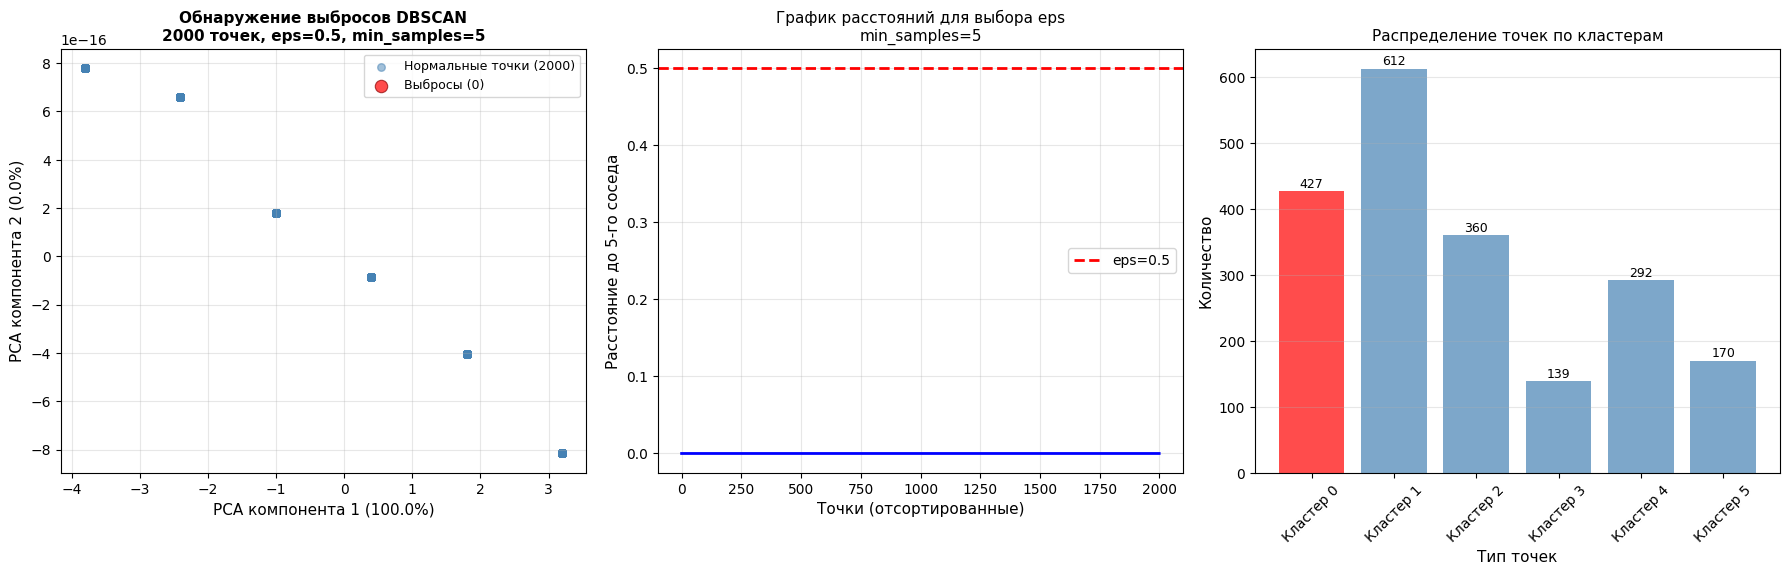

In [24]:
if isinstance(X, pd.DataFrame):
    X_array = X.values
    feature_names = X.columns.tolist()
else:
    X_array = X
    feature_names = [f'Feature_{i}' for i in range(X_array.shape[1])]

print(f"Размер данных: {X_array.shape}")
print(f"Признаки: {feature_names[:5]}...")

sample_size = min(2000, len(X_array))
print(f"\nБерем подвыборку из {sample_size} точек для обнаружения выбросов")

np.random.seed(42)
sample_indices = np.random.choice(len(X_array), size=sample_size, replace=False)
X_sample = X_array[sample_indices]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)
print("Данные стандартизированы")

print("ПОИСК ОПТИМАЛЬНЫХ ПАРАМЕТРОВ ДЛЯ ОБНАРУЖЕНИЯ ВЫБРОСОВ")

eps_values = [0.2, 0.3, 0.5, 0.8, 1.0]
min_samples_values = [3, 5, 8, 10]

best_params = None
best_outlier_ratio = None
best_labels = None

print("\nТестирование параметров:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_test = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
        labels_test = dbscan_test.fit_predict(X_scaled)

        n_outliers_test = list(labels_test).count(-1)
        outlier_ratio = n_outliers_test / len(labels_test)
        n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)

        status = "✓" if 0.05 < outlier_ratio < 0.3 else " "
        print(f"  {status} eps={eps}, min_samples={min_samples}: "
              f"выбросов={n_outliers_test} ({outlier_ratio*100:.1f}%), кластеров={n_clusters}")

        if 0.05 < outlier_ratio < 0.3:
            if best_params is None or abs(outlier_ratio - 0.15) < abs(best_outlier_ratio - 0.15):
                best_params = (eps, min_samples)
                best_outlier_ratio = outlier_ratio
                best_labels = labels_test

if best_params:
    eps, min_samples = best_params
    labels = best_labels
    print(f"\n✓ Выбраны оптимальные параметры: eps={eps}, min_samples={min_samples}")
    print(f"  Доля выбросов: {best_outlier_ratio*100:.1f}%")
else:
    eps, min_samples = 0.5, 5
    print(f"\n⚠ Используем параметры по умолчанию: eps={eps}, min_samples={min_samples}")
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan.fit_predict(X_scaled)

n_outliers = list(labels).count(-1)
n_inliers = len(labels) - n_outliers
outlier_ratio = n_outliers / len(labels)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("РЕЗУЛЬТАТЫ ОБНАРУЖЕНИЯ ВЫБРОСОВ")
print(f"  Параметры: eps={eps}, min_samples={min_samples}")
print(f"  Всего точек: {len(labels)}")
print(f"  Выбросы (шум): {n_outliers} ({outlier_ratio*100:.2f}%)")
print(f"  Нормальные точки: {n_inliers} ({n_inliers/len(labels)*100:.2f}%)")
print(f"  Количество кластеров: {n_clusters}")

outlier_indices = np.where(labels == -1)[0]
inlier_indices = np.where(labels != -1)[0]

print(f"\nСтатистика выбросов:")
if len(outlier_indices) > 0:
    print(f"  Индексы выбросов в выборке: первые 10: {outlier_indices[:10].tolist()}")

    from sklearn.metrics import pairwise_distances
    if len(inlier_indices) > 0 and len(outlier_indices) > 0:
        distances = pairwise_distances(X_scaled[outlier_indices[:min(100, len(outlier_indices))]],
                                      X_scaled[inlier_indices[:min(100, len(inlier_indices))]])
        print(f"  Среднее расстояние до ближайших нормальных точек: {np.min(distances, axis=1).mean():.3f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nОбъясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(
    X_pca[labels != -1, 0],
    X_pca[labels != -1, 1],
    c='steelblue',
    alpha=0.5,
    s=30,
    label=f'Нормальные точки ({n_inliers})'
)
axes[0].scatter(
    X_pca[labels == -1, 0],
    X_pca[labels == -1, 1],
    c='red',
    alpha=0.7,
    s=80,
    edgecolors='darkred',
    linewidth=0.8,
    label=f'Выбросы ({n_outliers})'
)

if len(outlier_indices) > 0:
    vis_outliers = np.random.choice(outlier_indices, size=min(20, len(outlier_indices)), replace=False)
    for i, idx in enumerate(vis_outliers):
        axes[0].annotate(f'O{idx}',
                        (X_pca[idx, 0], X_pca[idx, 1]),
                        fontsize=7,
                        alpha=0.7,
                        xytext=(5, 5),
                        textcoords='offset points')

axes[0].set_xlabel(f"PCA компонента 1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
axes[0].set_ylabel(f"PCA компонента 2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
axes[0].set_title(f"Обнаружение выбросов DBSCAN\n{len(labels)} точек, eps={eps}, min_samples={min_samples}",
                  fontsize=11, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

from sklearn.neighbors import NearestNeighbors

k = min_samples
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_scaled)
distances, indices = neigh.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

axes[1].plot(k_distances, 'b-', linewidth=2)
axes[1].axhline(y=eps, color='r', linestyle='--', linewidth=2, label=f'eps={eps}')
axes[1].set_xlabel('Точки (отсортированные)', fontsize=11)
axes[1].set_ylabel(f'Расстояние до {k}-го соседа', fontsize=11)
axes[1].set_title(f"График расстояний для выбора eps\nmin_samples={min_samples}", fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

unique_labels = np.unique(labels)
cluster_sizes = []
cluster_names = []

for label in unique_labels:
    if label == -1:
        cluster_sizes.append(n_outliers)
        cluster_names.append('Выбросы')
    else:
        size = np.sum(labels == label)
        cluster_sizes.append(size)
        cluster_names.append(f'Кластер {label}')

bars = axes[2].bar(cluster_names, cluster_sizes, color=['red'] + ['steelblue'] * (len(cluster_sizes)-1), alpha=0.7)
axes[2].set_xlabel('Тип точек', fontsize=11)
axes[2].set_ylabel('Количество', fontsize=11)
axes[2].set_title('Распределение точек по кластерам', fontsize=11)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

for bar, size in zip(bars, cluster_sizes):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(size), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()